# **1. Carga y exploración inicial**

### **Carga de DataSet - Online Retail.csv**


In [145]:
import pandas as pd, inspect
import numpy as np

try:
    df = pd.read_csv("https://raw.githubusercontent.com/leonelp399/Retail-Dataset---MCD/main/Online%20Retail.csv",sep=";")
    print(f"  Datos cargados exitosamente")
except Exception as e:
    print(f"✗ Error al cargar datos: {e}")



  Datos cargados exitosamente


In [2]:
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,1/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,1/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,1/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,1/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,1/12/2010 08:26,3.39,17850.0,United Kingdom


Observaciones:

- InvoiceNo: Corresponde al número de factura que identifica cada transacción.
- StockCode: Representa el código de stock asociado a cada producto.
- Description: Contiene la descripción del producto. Dado que no existe un código de producto, podría considerarse como identificador alternativo.
- Quantity: Indica la cantidad de unidades del producto adquiridas en la transacción.
- InvoiceDate: Registro de fecha y hora en que se emitió la factura.
- UnitPrice: Indica el precio unitario del producto.
- CustomerID: Es el identificador único asignado a cada cliente.
- Country: Señala el país de origen del cliente.

In [81]:
print("Cantidad de Filas: ", df.shape[0])
print("Cantidad de Columnas o Variables: ", df.shape[1])

Cantidad de Filas:  541909
Cantidad de Columnas o Variables:  8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [82]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### **Analisis de datos erróneos**

Se creó la función analisis_datos, la cual evaluan los siguientes criterios:

- Valores faltantes: Genera un DataFrame que muestra la cantidad y el porcentaje de valores nulos por variable, permitiendo identificar variables con información vacia.

- Duplicados: Detecta registros duplicados mediante el método duplicated().

- Valores negativos o cero: Analiza las columnas Quantity y UnitPrice para identificar registros con valores negativos o iguales a cero. Esta verificación se incluyó debido a que, al aplicar df.describe(), se observó la presencia de en los valores mínimos como negativos, no tiene sentido realizar ventas con precio o cantidad de unidad negativo o igual ha cero.

- Transacciones canceladas: Identifica facturas canceladas analizando la columna InvoiceNo, cuyo tipo de dato es object, presenta el carácter "C" al inicio del número de factura. Estos registros corresponden a transacciones canceladas, tambien indicar que las cantidades de producto aparecen con valores negativos en dichas filas

In [146]:
def analisis_datos(df):

    n = len(df)
    d = df.copy()
    d["InvoiceNo"] = d["InvoiceNo"].astype(str)

    # Parseo analizis_datosrobusto de fechas (por si vienen en dd/mm/yyyy)
    if not np.issubdtype(d["InvoiceDate"].dtype, np.datetime64):
        d["InvoiceDate"] = pd.to_datetime(d["InvoiceDate"], errors="coerce",
                                          format="mixed", dayfirst=True)
        mnat = d["InvoiceDate"].isna().sum()
        if mnat:
            print(f"[Aviso] Fechas no parseadas: {mnat:,}. Se mantienen como NaT.")

    es_cancel = d["InvoiceNo"].str.startswith("C")

    # 1) Faltantes
    print("1) VALORES FALTANTES")
    miss = d.isnull().sum()
    print(pd.DataFrame({
        "Columna": miss.index,
        "Valores Faltantes": miss.values,
        "Porcentaje": (100*miss/n).round(4)
    }).to_string(index=False))

    # 2) Duplicados
    print(f"\n2) DUPLICADOS EXACTOS: {d.duplicated().sum():,}")

    # 3) Cancelaciones + pareo
    canc = d[es_cancel].copy()
    print(f"\n3) CANCELACIONES: {len(canc):,} ({100*len(canc)/n:.2f}%)")
    if not canc.empty:
        print(f"   Rango Quantity canceladas: [{canc['Quantity'].min()}, {canc['Quantity'].max()}]")

        # detectar pares venta↔crédito
        sales = d[~es_cancel].copy()
        sales_pos = sales[sales["Quantity"] > 0].copy()
        creds_neg = canc[canc["Quantity"] < 0].copy()

        # preparar claves y magnitud de cantidad
        key = ["CustomerID", "StockCode", "UnitPrice"]
        sales_pos = sales_pos.assign(idx_sale=sales_pos.index,
                                     abs_qty_sale=sales_pos["Quantity"].abs())
        creds_neg = creds_neg.assign(idx_credit=creds_neg.index,
                                     abs_qty_credit=creds_neg["Quantity"].abs())

        cand = (sales_pos.merge(
                    creds_neg,
                    left_on=key + ["abs_qty_sale"],
                    right_on=key + ["abs_qty_credit"],
                    how="inner",
                    suffixes=("_sale","_credit"))
                )

        # crédito posterior a la venta
        cand = cand[cand["InvoiceDate_credit"] > cand["InvoiceDate_sale"]].copy()

        # elegir match 1↔1: crédito más cercano en el tiempo por venta
        cand["delta_sec"] = (cand["InvoiceDate_credit"] - cand["InvoiceDate_sale"]).dt.total_seconds()
        cand = cand.sort_values(["idx_sale", "delta_sec"]).drop_duplicates("idx_sale", keep="first")
        cand = cand.sort_values(["idx_credit", "delta_sec"]).drop_duplicates("idx_credit", keep="first")

        matched_sales   = set(cand["idx_sale"])
        matched_credits = set(cand["idx_credit"])

        print(f"   • Cancelaciones con PAR encontrado: {len(matched_credits):,}")
        print(f"   • Cancelaciones SIN par: {len(canc) - len(matched_credits):,}")
        print(f"   • Ventas emparejadas: {len(matched_sales):,}")

    # 4) Negativos/cero (excluye cancelaciones)
    base = d[~es_cancel]
    qty_le0  = (base["Quantity"]  <= 0).sum()
    prc_le0  = (base["UnitPrice"] <= 0).sum()
    print("\n4) NEGATIVOS / CERO (excluye cancelaciones)")
    print(f"   - Quantity <= 0 : {qty_le0:,} ({100*qty_le0/len(base):.2f}%)")
    print(f"   - UnitPrice<= 0 : {prc_le0:,} ({100*prc_le0/len(base):.2f}%)")

analisis_datos(df)

1) VALORES FALTANTES
    Columna  Valores Faltantes  Porcentaje
  InvoiceNo                  0      0.0000
  StockCode                  0      0.0000
Description               1454      0.2683
   Quantity                  0      0.0000
InvoiceDate                  0      0.0000
  UnitPrice                  0      0.0000
 CustomerID             135080     24.9267
    Country                  0      0.0000

2) DUPLICADOS EXACTOS: 5,268

3) CANCELACIONES: 9,288 (1.71%)
   Rango Quantity canceladas: [-80995, -1]
   • Cancelaciones con PAR encontrado: 2,883
   • Cancelaciones SIN par: 6,405
   • Ventas emparejadas: 2,883

4) NEGATIVOS / CERO (excluye cancelaciones)
   - Quantity <= 0 : 1,336 (0.25%)
   - UnitPrice<= 0 : 2,517 (0.47%)


Cantidad de registros que presentan valor vacio en las variables Description y CustomerID

In [ ]:
df_data_faltante = df[df['Description'].isnull() & df['CustomerID'].isnull()]
print(f'Cantidad de registro con valor nulo en Description y CustomerID \n{len(df_data_faltante)}')

Cantidad de registro con valor nulo en Description y CustomerID 
1454


Observamos

- Se identificó que 9,288 registros corresponden a transacciones canceladas, lo que representa aproximadamente el 1.7 % del total. Asimismo, se observó que los valores faltantes en la variable Description (1,454 casos) coinciden con valores nulos en CustomerID, lo que sugiere una relación directa entre ambas variables, posiblemente asociada a registros incompletos o anulados.

- se detectaron 5,268 registros duplicados y un 24.9 % de observaciones con CustomerID faltante, lo cual refuerza la necesidad de una depuración previa al análisis, especialmente para garantizar la coherencia entre los identificadores de clientes y las descripciones de los productos.

<br>

#### **Depuración de datos errones**

In [147]:
def depurar_datos(df):
    import pandas as pd
    import numpy as np

    d = df.copy()
    d["InvoiceNo"] = d["InvoiceNo"].astype(str)

    # --- Parseo robusto de fechas (mixtos y dd/mm/yyyy)
    if not np.issubdtype(d["InvoiceDate"].dtype, np.datetime64):
        d["InvoiceDate"] = pd.to_datetime(d["InvoiceDate"], errors="coerce",
                                          format="mixed", dayfirst=True)
        mask_nat = d["InvoiceDate"].isna()
        if mask_nat.any():
            d.loc[mask_nat, "InvoiceDate"] = pd.to_datetime(
                d.loc[mask_nat, "InvoiceDate"], errors="coerce",
                format="mixed", dayfirst=False
            )

    # Flag de cancelación (por número de factura)
    d["is_cancel"] = d["InvoiceNo"].str.startswith("C")

    n0 = len(d)

    # 1) Eliminar CustomerID nulo (toda la población)
    n_sin_cliente = d["CustomerID"].isna().sum()
    d = d.dropna(subset=["CustomerID"]).copy()
    print(f"1) Filas sin CustomerID eliminadas: {n_sin_cliente:,}")

    # 2) Eliminar duplicados exactos
    dups = d.duplicated().sum()
    d = d.drop_duplicates().copy()
    print(f"2) Duplicados exactos eliminados: {dups:,}")

    # 3) Eliminar pares venta↔crédito (mismo cliente, producto, precio y |qty|, crédito posterior)
    #    - Mantiene sólo el resto; borra ambos registros del par
    #    - Usamos merge por clave + abs(cantidad) y aplicamos dt_credit > dt_sale
    sales = d[(~d["is_cancel"]) & (d["Quantity"] > 0)].copy()
    creds = d[( d["is_cancel"]) & (d["Quantity"] < 0)].copy()

    # guarda índices para poder eliminar por fila exacta
    sales = sales.assign(index_sale=sales.index, abs_qty_sale=sales["Quantity"].abs())
    creds = creds.assign(index_credit=creds.index, abs_qty_credit=creds["Quantity"].abs())

    key_cols = ["CustomerID", "StockCode", "UnitPrice"]

    cand = (sales.merge(
                creds,
                left_on=key_cols + ["abs_qty_sale"],
                right_on=key_cols + ["abs_qty_credit"],
                how="inner",
                suffixes=("_sale", "_credit"))
            )

    # crédito posterior a la venta
    cand = cand[cand["InvoiceDate_credit"] > cand["InvoiceDate_sale"]].copy()

    # Emparejar 1↔1: elige el crédito más cercano en el tiempo por venta
    cand["delta_sec"] = (cand["InvoiceDate_credit"] - cand["InvoiceDate_sale"]).dt.total_seconds()
    cand = cand.sort_values(["index_sale", "delta_sec"])

    # primero asegúrate de no repetir venta
    cand = cand.drop_duplicates(subset=["index_sale"], keep="first")
    # luego evita reutilizar un mismo crédito
    cand = cand.sort_values(["index_credit", "delta_sec"])
    cand = cand.drop_duplicates(subset=["index_credit"], keep="first")

    to_drop = set(cand["index_sale"].tolist() + cand["index_credit"].tolist())
    d = d.drop(index=to_drop, errors="ignore").copy()
    print(f"3) Pares venta↔crédito eliminados (ambas filas): {len(to_drop)//2:,} pares")

    # 4) Quitar el resto de cancelados (cualquier 'C...' que no se emparejó arriba)
    rem_canc = d["is_cancel"].sum()
    d = d[~d["is_cancel"]].copy()
    print(f"4) Cancelados restantes eliminados: {rem_canc:,}")

    # 5) Quitar Quantity<=0 o UnitPrice<=0
    bad_qty_price = ((d["Quantity"] <= 0) | (d["UnitPrice"] <= 0)).sum()
    d = d[(d["Quantity"] > 0) & (d["UnitPrice"] > 0)].copy()
    print(f"5) Filas con Quantity<=0 o UnitPrice<=0 eliminadas: {bad_qty_price:,}")

    # Resumen final
    print("\n— Resumen —")
    print(f"Registros iniciales : {n0:,}")
    print(f"Registros finales   : {len(d):,} ({100*len(d)/n0:.1f}% del original)")

    return d

df_clean = depurar_datos(df)

1) Filas sin CustomerID eliminadas: 135,080
2) Duplicados exactos eliminados: 5,225
3) Pares venta↔crédito eliminados (ambas filas): 2,758 pares
4) Cancelados restantes eliminados: 6,114
5) Filas con Quantity<=0 o UnitPrice<=0 eliminadas: 40

— Resumen —
Registros iniciales : 541,909
Registros finales   : 389,934 (72.0% del original)


Observamos

Se ejecutó la depuración conforme al análisis de calidad previo, eliminándose 151,975 registros (≈ 28.0 % del total inicial de 541,909). El detalle es:

- Filas sin CustomerID: 135,080 (24.93 %).

- Duplicados exactos: 5,225 (0.96 %).

- Pares venta ↔ crédito eliminados (ambas filas): 2,758 pares = 5,516 filas (1.02 %).

- Cancelaciones restantes (sin par): 6,114 (1.13 %).

- Valores no válidos (Quantity ≤ 0 o UnitPrice ≤ 0, excluye cancelaciones): 40 (0.01 %).

Como resultado, el dataset final queda en 389,934 registros (≈ 72.0 % del original), con menor ruido por anulaciones, duplicados y claves de cliente vacías, y preparado para un EDA y modelado más confiables.

# **2. Análisis de distribuciones**



In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from plotnine import ggplot, aes, geom_histogram, geom_density, labs, theme_minimal, facet_wrap
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy.stats import skew, kurtosis
import calendar
from matplotlib.ticker import PercentFormatter

<br>

### **Histogramas**


In [149]:
summary_stats = df_clean[['UnitPrice', 'Quantity']].describe()
extra_stats = df_clean[['UnitPrice', 'Quantity']].agg(['skew', 'kurt'])

full_summary = pd.concat([summary_stats, extra_stats])
print(full_summary.round(3))

        UnitPrice    Quantity
count  389934.000  389934.000
mean        3.075      12.640
std        21.322      42.264
min         0.001       1.000
25%         1.250       2.000
50%         1.950       6.000
75%         3.750      12.000
max      8142.750    4800.000
skew      224.212      29.951
kurt    67738.956    1789.301


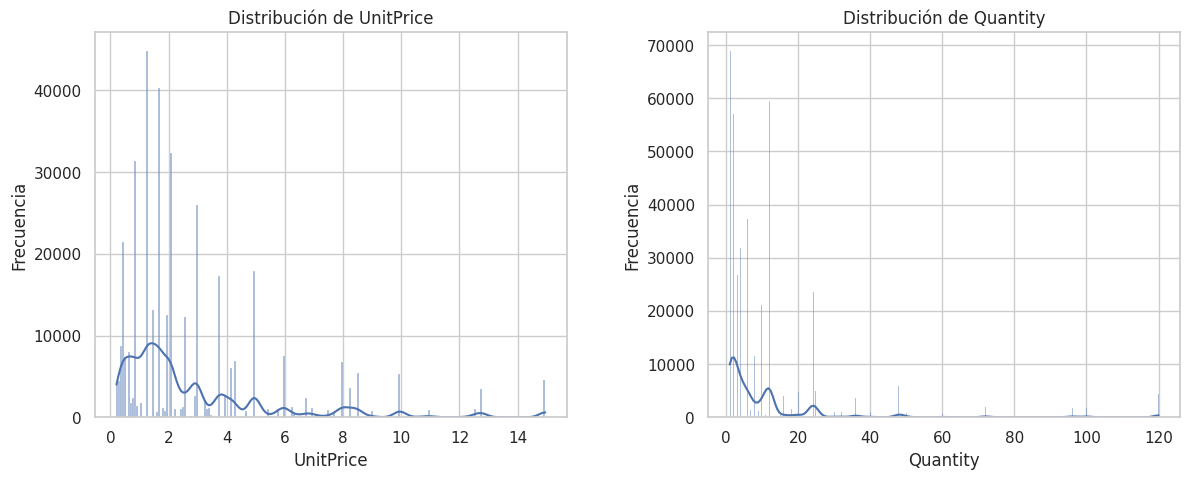

In [150]:
sns.set(style="whitegrid")

def plot_dist(ax_hist, s, title, bins='fd', clip_pct=None, kde=True):
    s = pd.to_numeric(s, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()

    # Recorte opcional de colas (winsorización “visual”)
    if clip_pct is not None:
        lo, hi = np.percentile(s, [clip_pct, 100-clip_pct])
        s = s.clip(lo, hi)

    # Histograma
    sns.histplot(s, bins=bins, kde=kde, ax=ax_hist)
    ax_hist.set_title(f'Distribución de {title}')
    ax_hist.set_xlabel(title)
    ax_hist.set_ylabel('Frecuencia')

# ---- Ploteo lado a lado (hist arriba, box abajo) para cada variable ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.subplots_adjust(wspace=0.3)

# Histogramas
plot_dist(axes[0], df_clean['UnitPrice'], 'UnitPrice', bins='fd', clip_pct=1, kde=True)
plot_dist(axes[1], df_clean['Quantity'], 'Quantity', bins='fd', clip_pct=1, kde=True)

plt.show()

Observamos

- UnitPrice muestra una asimetría positiva extrema (skew = 224; kurtosis ≈ 67,739). La masa de datos se concentra en precios bajos (Q1 = 1.25, mediana = 1.95, Q3 = 3.75) y existe una cola muy larga con valores aislados hasta 8,142.75. Esto sugiere outliers severos (posibles errores de captura, unidades distintas, costos de envío o packs).
- Quantity también presenta asimetría positiva pronunciada (skew = 29.95; kurtosis ≈ 1,789). La mayoría de las líneas son pedidos pequeños (Q1 = 2, mediana = 6, Q3 = 12; media = 12.64) con una cola larga de pedidos muy grandes (máx. = 4,800).

<br>

### **BoxPlot - Outliers**

In [152]:

def prep_series(s):
    s = pd.to_numeric(s, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    return s

def tukey_stats(s, k=1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    mask_low = s < lo
    mask_high = s > hi
    return {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'LowerFence': lo, 'UpperFence': hi,
        'OutliersLow': mask_low.sum(),
        'OutliersHigh': mask_high.sum(),
        'TotalOutliers': (mask_low | mask_high).sum(),
        'PctOutliers': (mask_low | mask_high).mean() * 100
    }

def outlier_summary(df, cols, k=1.5):
    rows = []
    for c in cols:
        s = prep_series(df[c])
        st = tukey_stats(s, k)
        out_hi = s[s > st['UpperFence']]
        rows.append({
            'Variable': c,
            'Cantidad': s.size,
            'Q1': st['Q1'], 'Q3': st['Q3'], 'IQR': st['IQR'],
            'LowerFence': st['LowerFence'], 'UpperFence': st['UpperFence'],
            'Outliers Totales': int(((s < st['LowerFence']) | (s > st['UpperFence'])).sum()),
            'Pct Outliers': ((s > st['UpperFence']) | (s < st['LowerFence'])).mean() * 100,
            'Max Outlier': out_hi.max() if not out_hi.empty else None
        })
    return pd.DataFrame(rows)

cols = ['UnitPrice', 'Quantity']
out_tbl = outlier_summary(df_clean, cols)
out_tbl.round(3)

,Variable,Cantidad,Q1,Q3,IQR,LowerFence,UpperFence,Outliers Totales,Pct Outliers,Max Outlier
0,UnitPrice,389934,1.25,3.75,2.5,-2.5,7.5,33501,8.591,8142.75
1,Quantity,389934,2.00,12.00,10.0,-13.0,27.0,25264,6.479,4800.00


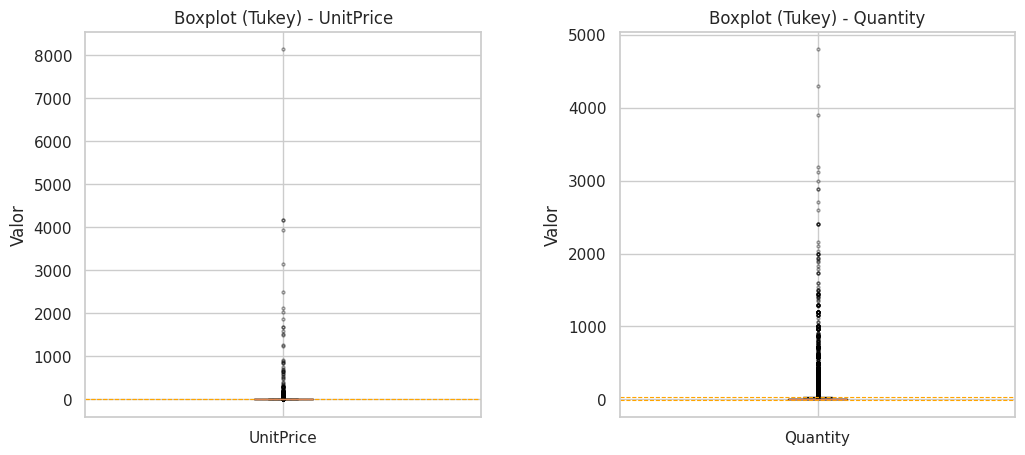

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.35)

# --- Loop sobre variables ---
for ax, col in zip(axes, cols):
    s = prep_series(df_clean[col])
    stats = tukey_stats(s)

    # Boxplot con método Tukey (whis=1.5)
    bp = ax.boxplot(
        s.values, vert=True, whis=1.5,
        showfliers=True,
        flierprops={'markersize': 2, 'alpha': 0.4, 'color': 'red'}
    )

    # Líneas horizontales con los fences
    ax.axhline(stats['LowerFence'], linestyle='--', linewidth=0.8, color='orange')
    ax.axhline(stats['UpperFence'], linestyle='--', linewidth=0.8, color='orange')

    # Etiquetas y anotaciones
    ax.set_title(f'Boxplot (Tukey) - {col}')
    ax.set_xticks([1])
    ax.set_xticklabels([col])
    ax.set_ylabel('Valor')

plt.show()



Observamos en los BoxPlots

UnitPrice
- 8.59 % de outliers, todos por arriba del límite, a simple vista podemos observar que hay valores de precio mayores a los 3000, podria considerar realizar un analisis desde los valore mayores a 1000
- Revisar si son artículos premium o errores de carga

Quantity
- 6.48 % de outliers, todos por arriba del límite, podemos observar cantidades de unidades muy por encima de 3000

<br>

### **Definición de Variable Objetivo y Creación de Nuevas Variables**

Considerando que la variable objetivo será Revenue (Ganancia) (resultado del producto entre Quantity y UnitPrice), esta permitirá realizar un análisis detallado del comportamiento de las ventas y el desempeño comercial.

A partir de esta variable, es posible desarrollar los siguientes análisis:

- Distribución de ingresos por país, cliente o periodo temporal (mes, año).

- Identificación de los productos más rentables y su contribución a las ventas totales.

- Análisis temporal de las horas y días con mayor volumen de ventas.

In [155]:
# Conversión del campo 'InvoiceDate' a formato datetime.
# Se usa 'dayfirst=True' porque las fechas están en formato día/mes/año.
# 'errors="coerce"' convierte los valores no válidos en NaT (Not a Time) en lugar de lanzar un error.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], dayfirst=True, errors='coerce')

# Extracción del año a partir del campo de fecha.
df_clean['Year'] = df_clean['InvoiceDate'].dt.year

# Extracción del número de mes (1–12).
df_clean['Month'] = df_clean['InvoiceDate'].dt.month

# Obtención del nombre completo del mes (Enero, Febrero, ...).
df_clean['MonthName'] = df_clean['InvoiceDate'].dt.month_name()

# Obtención del nombre del día de la semana (Lunes, Martes, ...).
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

# Extracción de la hora (0–23) a partir de la marca temporal de la factura.
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# Creación de un campo 'YearMonth' con el periodo año-mes, útil para análisis mensuales.
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Cálculo del ingreso (Revenue) multiplicando la cantidad por el precio unitario.
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancel,Year,Month,MonthName,DayOfWeek,Hour,YearMonth,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,2010,12,December,Wednesday,8,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010,12,December,Wednesday,8,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,2010,12,December,Wednesday,8,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010,12,December,Wednesday,8,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010,12,December,Wednesday,8,2010-12,20.34


<br>

### **Distribución de la variable objetivo**

In [156]:
y = df_clean["Revenue"].dropna()

desc = {
    "count": y.size,
    "mean": y.mean(),
    "median": y.median(),
    "std": y.std(),
    "p01": y.quantile(0.01),
    "p25": y.quantile(0.25),
    "p50": y.quantile(0.50),
    "p75": y.quantile(0.75),
    "p99": y.quantile(0.99),
    "skew": skew(y),
    "kurtosis": kurtosis(y, fisher=True)
}

pd.Series(desc).round(3)

,0
count,389934.000
mean,21.765
median,11.900
std,94.866
p01,0.550
p25,4.950
p50,11.900
p75,19.800
p99,201.600
skew,190.639


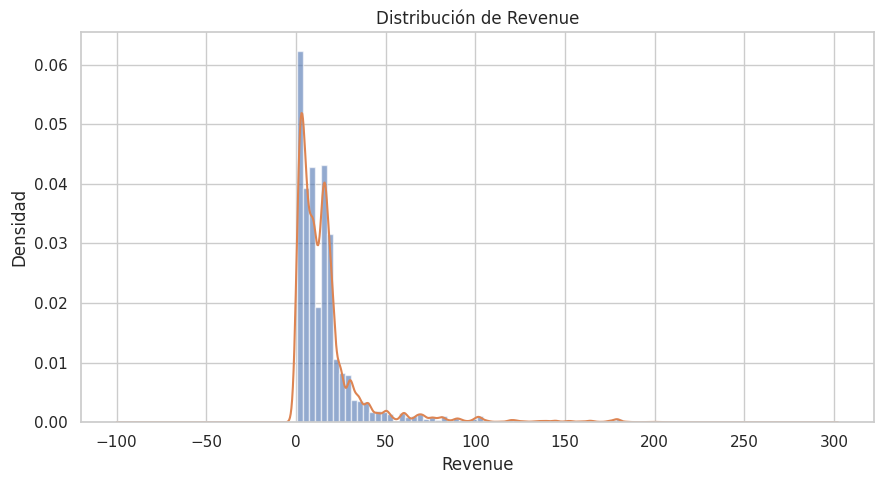

In [157]:
# Filtrar valores extremos (1%–99%)
y_trim = y[(y >= y.quantile(0.01)) & (y <= y.quantile(0.99))]

plt.figure(figsize=(9,5))
plt.hist(y_trim, bins=60, alpha=0.6, density=True)
pd.Series(y_trim).plot(kind="kde")
plt.title("Distribución de Revenue")
plt.xlabel("Revenue"); plt.ylabel("Densidad")
plt.tight_layout(); plt.show()

Observamos
- Revenue presenta asimetría positiva marcada. La masa principal se concentra entre ≈ 5 y 20 (Q1=4.95, mediana=11.9, Q3=19.8). La media (21.77) queda por encima de la mediana, arrastrada por la cola derecha. El recorte 1–99% permite ver el “cuerpo” de la distribución sin que los extremos dominen la escala.

In [158]:
cols2 = ['Revenue']
out_tbl2 = outlier_summary(df_clean, cols2)
out_tbl2.round(3)

,Variable,Cantidad,Q1,Q3,IQR,LowerFence,UpperFence,Outliers Totales,Pct Outliers,Max Outlier
0,Revenue,389934,4.95,19.8,14.85,-17.325,42.075,30747,7.885,38970.0


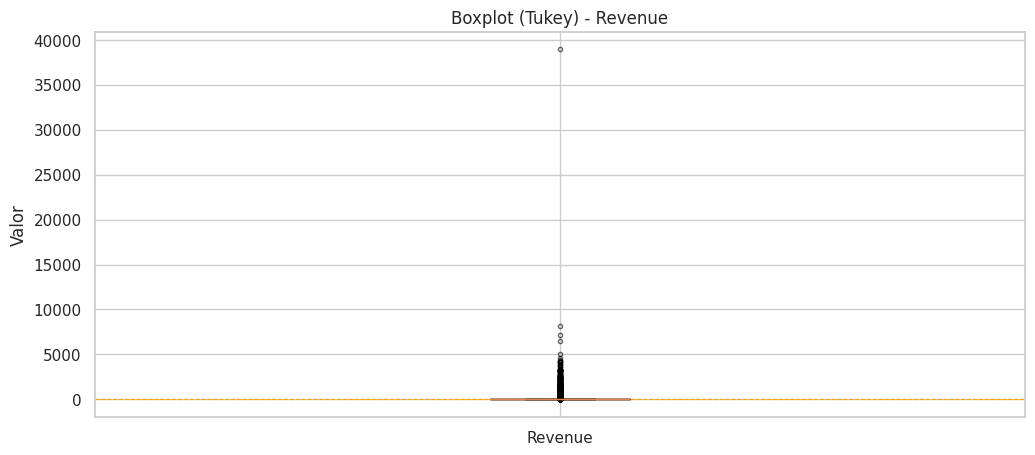

In [159]:
col = "Revenue"
s = prep_series(df_clean[col])
if s.empty:
    raise ValueError(f"La serie {col} está vacía tras limpiar (NaN/No numéricos).")

stats = tukey_stats(s)

# --- Plot
fig, ax = plt.subplots(figsize=(12, 5))  # <- aquí SÍ creamos 'ax'
# plt.subplots_adjust(wspace=0.35)  # innecesario con un solo subplot

bp = ax.boxplot(
    s.values, vert=True, whis=1.5, showfliers=True,
    flierprops=dict(marker='o', markersize=3, markerfacecolor='none', alpha=0.6)
)

# Líneas horizontales con los fences de Tukey
ax.axhline(stats['LowerFence'], linestyle='--', linewidth=0.8, color='orange')
ax.axhline(stats['UpperFence'], linestyle='--', linewidth=0.8, color='orange')

ax.set_title(f'Boxplot (Tukey) - {col}')
ax.set_xticks([1]); ax.set_xticklabels([col])
ax.set_ylabel('Valor')

plt.show()

Observamos
- La mayoría de las ventas se concentra entre 4.95 (Q1) y 19.80 (Q3); la mediana es alrededor de 11.9.

- Con la regla de Tukey, el límite superior del rango normal es aproximadamente 42.08; el inferior sería negativo y no aplica porque Revenue es ≥ 0.

- Hay 30,747 outliers (7.89% del total), todos por encima del límite superior.

- Se observan valores extremos de varios miles (en el gráfico aparecen hasta ~38970), por lo que la media queda inflada respecto a la mediana.

<br>

### **Comparar distribuciones**



In [117]:
def plot_box_mean_quartiles(df, cat, target="Revenue", top=12, min_count=50, title=None):
    # Filtrar categorías principales
    vc = df[cat].value_counts().head(top).index
    sub = df[df[cat].isin(vc)].copy()

    # --- Orden natural ---
    if cat == "MonthName":
        order_levels = [m for m in list(calendar.month_name)[1:] if m in sub[cat].unique()]
    elif cat == "DayOfWeek":
        order_levels = [d for d in ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"] if d in sub[cat].unique()]
    elif cat == "Hour":
        order_levels = sorted(sub[cat].dropna().unique().astype(int))
    else:
        order_levels = vc

    # --- Calcular estadísticos ---
    stats = (
        sub.groupby(cat)[target]
        .agg(["count", "mean", "median", lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])
        .reindex(order_levels)
    )
    stats.columns = ["n", "mean", "median", "q1", "q3"]
    stats = stats.round(2)

    # --- Crear figura ---
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        x=cat, y=target, data=sub, order=order_levels,
        hue=cat, legend=False, palette="pastel", showfliers=False
    )

    # Añadir medias (rojas)
    sns.pointplot(
        x=cat, y=target, data=sub, order=order_levels,
        color="red", errorbar=None, markers="o", linestyles="--", label="Media"
    )

    # --- Etiquetas numéricas ---
    for i, row in enumerate(stats.itertuples()):
        # Media
        plt.text(i, row.mean, f"{row.mean:,.0f}", color="black", ha="center", va="bottom", fontsize=9, fontweight="bold")
        # Q1, mediana, Q3
        plt.text(i, row.q1, f"{row.q1:,.0f}", color="blue", ha="center", va="top", fontsize=8)
        plt.text(i, row.median, f"{row.median:,.0f}", color="darkgreen", ha="center", va="bottom", fontsize=8)
        plt.text(i, row.q3, f"{row.q3:,.0f}", color="blue", ha="center", va="bottom", fontsize=8)

    # --- Ajustes visuales ---
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(target)
    plt.title(title or f"{target} por {cat}")
    plt.legend()
    plt.tight_layout()
    plt.show()

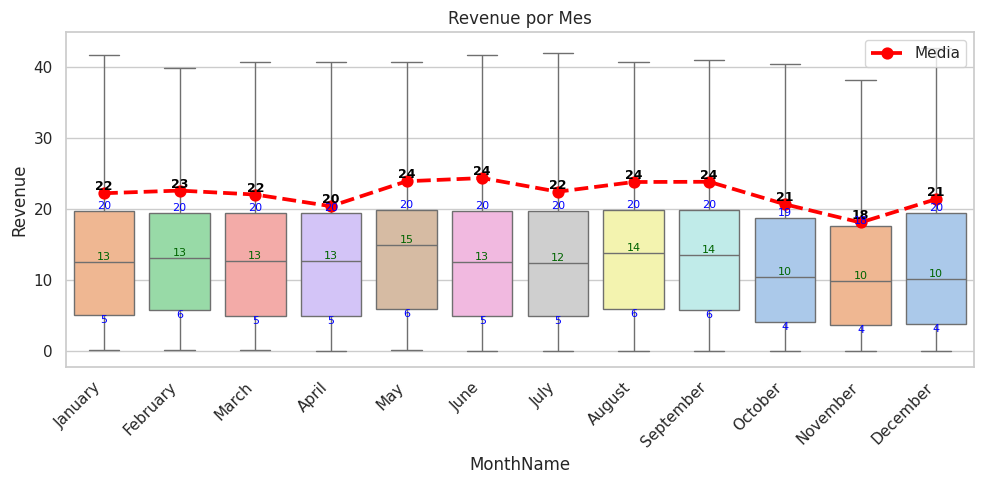

In [107]:
plot_box_mean_quartiles(df_clean, "MonthName", "Revenue", title="Revenue por Mes")

Observamos

- Patrón estable: Las distribuciones son muy similares entre meses: Q1 ~4–6, mediana ~10–15, Q3 ~18–20. La forma se mantiene sesgada a la derecha (la media > mediana en todos los meses).

- Meses con media más alta: Mayo, Junio, Agosto y Septiembre (≈ 24).

- Meses con media más baja: Noviembre (≈ 18)

- Dispersión similar: La amplitud intercuartílica es prácticamente la misma; los boxplots llegan hasta ~20 y los bigotes (Tukey) ~40, indicando variabilidad comparable entre meses.

Implicación: No se observa una estacionalidad fuerte en la parte central de la distribución; las diferencias son moderadas. Para acciones comerciales, priorizar Jun–Sep (ligeramente superiores)

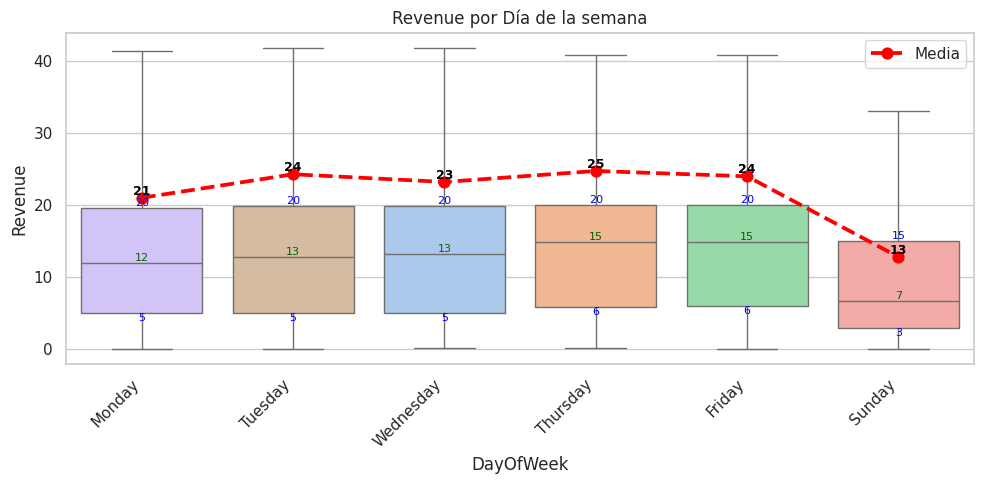

In [118]:
plot_box_mean_quartiles(df_clean, "DayOfWeek", "Revenue", title="Revenue por Día de la semana")

Observamos
- Patrón laboral estable: De lunes a viernes las distribuciones son muy parecidas: Q1 ≈ 5–6, mediana ≈ 12–15, Q3 ≈ 20; la media se mantiene por encima de la mediana (sesgo a la derecha).

- Picos de media: Jueves (25) es el más alto, seguido de martes y viernes (24).

- Fin de semana más débil: Domingo cae con media ~13, mediana ~7 y Q1 bajo (≈ 3), indicando tickets más pequeños y/o menos transacciones.

- Dispersión comparable: Los rangos intercuartílicos son similares entre días; los bigotes llegan ~40, sugiriendo colas superiores en todos los casos.

Implicación: No hay estacionalidad fuerte intrasemanal en el centro de la distribución, pero sí un efecto fin de semana claro. Para campañas o recursos operativos, priorizar jueves–viernes (mayor ingreso promedio) y considerar promociones o tácticas específicas para domingo.

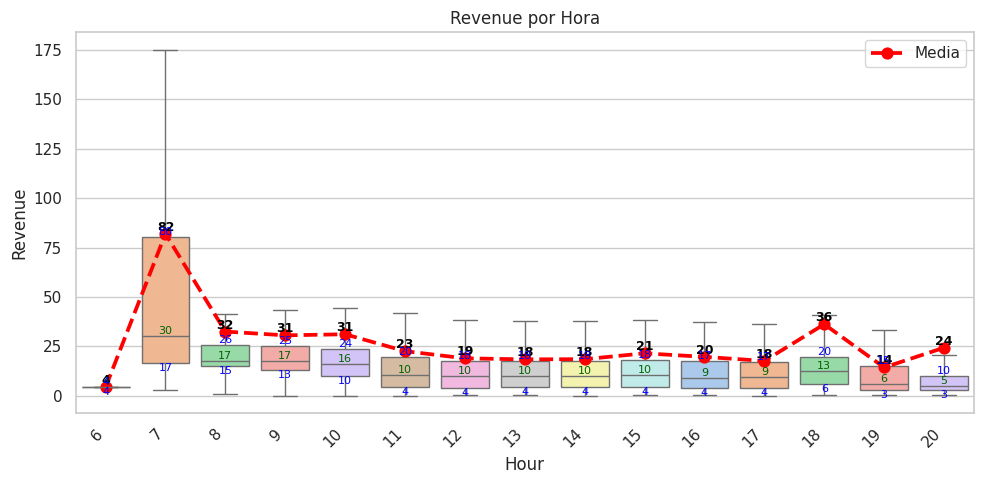

In [119]:
plot_box_mean_quartiles(df_clean, "Hour", "Revenue", top=24, title="Revenue por Hora")

Observamos
- Una concentración marcada en las primeras horas del día, con un pico muy alto alrededor de las 7:00 a.m., donde se registra el promedio más elevado de ganancias (82). Después de esa hora, los ingresos disminuyen de forma pronunciada y se mantienen relativamente bajos y estables durante el resto del día, con una leve subida en las 6:00 p.m. (36). Este comportamiento sugiere que la mayor actividad comercial ocurre temprano en la mañana, posiblemente por procesos automáticos, ventas programadas o aperturas de jornada, mientras que el resto del día muestra un flujo regular y sostenido pero menor de transacciones.

# **3. Análisis de correlaciones**

<br>

### **Correlaciones con variables numéricas**


Correlaciones SPEARMAN con Revenue (Ganancia):

             rho  intensidad
Revenue    1.000  muy fuerte
Quantity   0.652      fuerte
UnitPrice  0.349    moderada
Year       0.006        nula
Month     -0.070        nula
Hour      -0.169       débil  



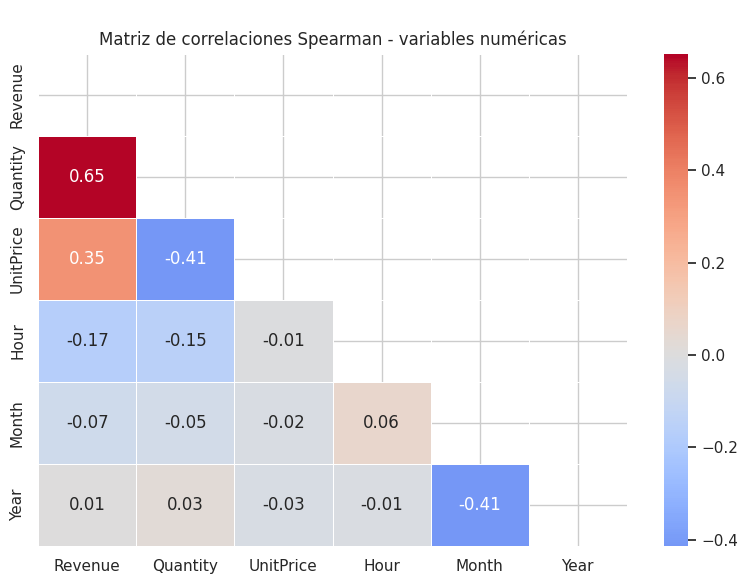

In [120]:
# 1) Selección de numéricas relevantes
num_cols = ['Revenue','Quantity','UnitPrice','Hour','Month','Year']
num_df = df_clean[num_cols].copy()

# 2) Matriz de correlaciones Spearman (todas vs todas)
corr_spearman = num_df.corr(method='spearman')

# 3) Ranking de correlaciones con Revenue
ranking = (corr_spearman['Revenue'].sort_values(ascending=False).to_frame('rho').round(3))

# 4) Etiquetas de intensidad según intervalor de spearman
def intensidad(abs_rho):
    if abs_rho < 0.10:  return 'nula'
    if abs_rho < 0.30:  return 'débil'
    if abs_rho < 0.50:  return 'moderada'
    if abs_rho < 0.70:  return 'fuerte'
    return 'muy fuerte'

ranking['intensidad'] = ranking['rho'].abs().apply(intensidad)
print('\nCorrelaciones SPEARMAN con Revenue (Ganancia):\n')
print(f'{ranking}  \n')

# 5) Heatmap Spearman
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))  # oculta triángulo superior (opcional)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_spearman,
    annot=True, fmt=".2f", cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white', mask=mask
)
plt.title('\nMatriz de correlaciones Spearman - variables numéricas')
plt.tight_layout()
plt.show()

Observamos

- El mapa y el ranking Spearman indican que Revenue está explicado sobre todo por Quantity (ρ≈0.65, relación fuerte) y en menor medida por UnitPrice (ρ≈0.35, moderada). Las variables temporales tienen poca o nula asociación con la ganancia a nivel transacción: Hour muestra una relación débil y negativa (ρ≈–0.17) y Month/Year son casi nulas. Además, se aprecia una relación inversa moderada entre Quantity y UnitPrice (ρ≈–0.41), consistente con compras de mayor volumen a menor precio (descuentos/paquetes). En resumen: el volumen vendido es el principal driver del Revenue, con el precio aportando en segundo plano y el calendario aportando poco en esta granularidad.

<br>

### **Multicolinealidad de variables**


    Variable       VIF Nivel
4      Month  1.134327  Baja
5       Year  1.130811  Baja
3       Hour  1.005643  Baja
1   Quantity  1.002907  Baja
2  UnitPrice  1.000383  Baja 




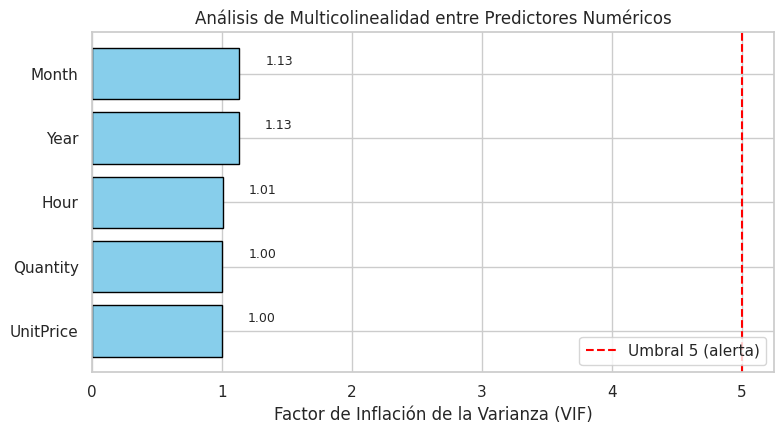

In [121]:
# definimos variables predictoras
Xcols = ["Quantity", "UnitPrice", "Hour", "Month", "Year"]
X = df_clean[Xcols].dropna().copy()

X_const = sm.add_constant(X)
vif = pd.DataFrame({
    "Variable": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i)
            for i in range(X_const.shape[1])]
})
vif = vif.query("Variable != 'const'").sort_values("VIF", ascending=False)

interpretacion = pd.cut(
    vif["VIF"],
    bins=[0, 1, 5, 10, float("inf")],
    labels=["Sin colinealidad", "Baja", "Moderada", "Alta"]
)
vif["Nivel"] = interpretacion
print(f'{vif} \n\n')

plt.figure(figsize=(8, 4.5))
bars = plt.barh(vif["Variable"], vif["VIF"], color="skyblue", edgecolor="black")
plt.axvline(5, color="red", linestyle="--", label="Umbral 5 (alerta)")
plt.xlabel("Factor de Inflación de la Varianza (VIF)")
plt.title("Análisis de Multicolinealidad entre Predictores Numéricos")
plt.legend(loc="lower right")
plt.gca().invert_yaxis()

# Mostrar valores sobre las barras
for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/3,
             f"{bar.get_width():.2f}", fontsize=9)

plt.tight_layout()
plt.show()




Observamos, que no hay multicolinealidad preocupante.

- El gráfico de VIF (Factor de Inflación de la Varianza) muestra que no existe multicolinealidad significativa entre las variables predictoras numéricas (Quantity, UnitPrice, Hour, Month y Year).
Todos los valores se encuentran alrededor de 1.0 a 1.13, muy por debajo del umbral crítico de 5, lo que indica que ninguna variable está explicando a otra de forma redundante.

- Esto significa que los predictores son independientes entre sí y pueden usarse simultáneamente en modelos estadísticos sin riesgo de distorsionar los coeficientes ni inflar los errores estándar. En síntesis, el conjunto de variables numéricas es estable y adecuado para modelado predictivo.

<br>

### **Scatter plots**

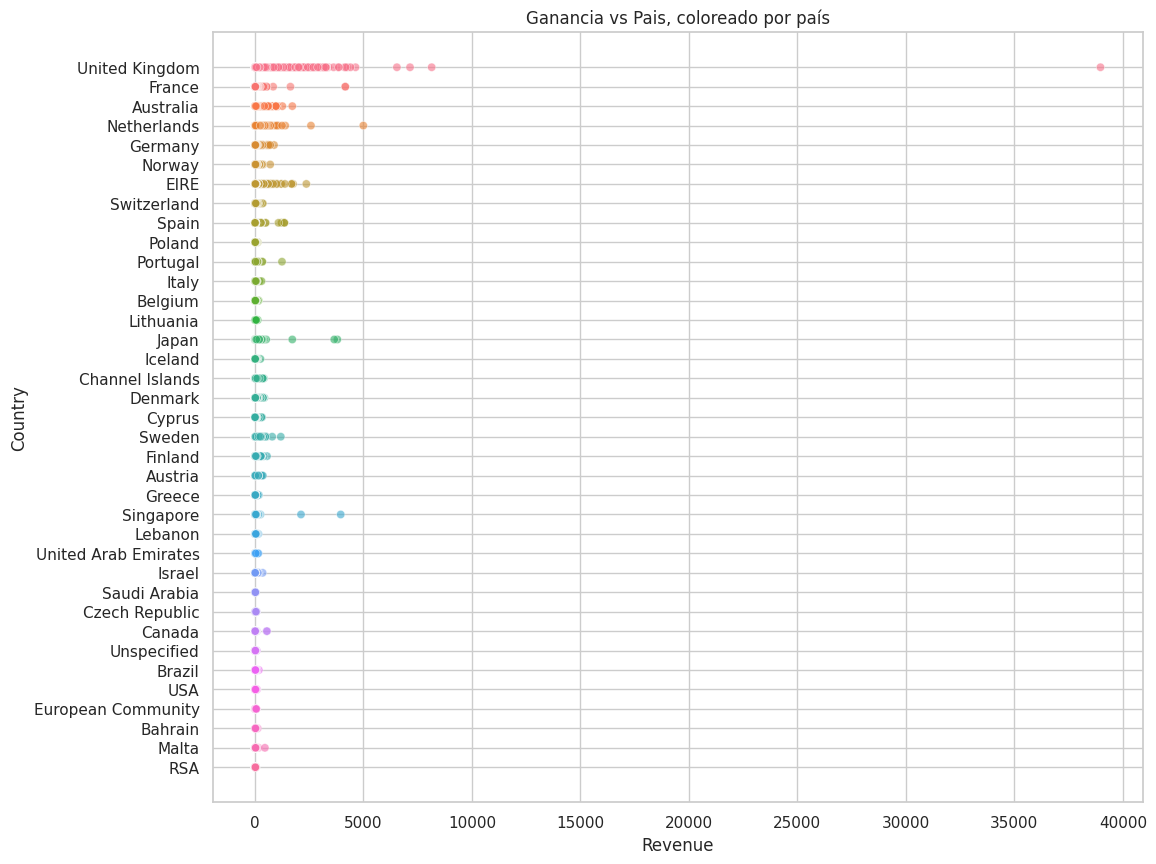

In [122]:
plt.figure(figsize=(12,10))
sns.scatterplot(
    data=df_clean,
    x='Revenue', y='Country',
    hue='Country', alpha=0.6, legend=False
)
plt.title('Ganancia vs Pais, coloreado por país')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.show()

Observamos
- El diagrama de dispersión muestra una relación no lineal y altamente concentrada, donde la mayoría de los países presentan valores de Revenue muy bajos y agrupados cerca del eje vertical, mientras que unos pocos puntos se alejan hacia la derecha, indicando ventas de alto valor.

- No se aprecia relación lineal entre país e ingreso, ya que los puntos no siguen una tendencia ascendente o descendente continua, pero sí se observa un patrón de dispersión desigual: el Reino Unido concentra la mayor cantidad de transacciones y amplitud de ingresos, mientras que otros países forman pequeños clústeres compactos con menor variabilidad.

- El resto de los países como Francia, Alemania, Países Bajos y Australia muestran volúmenes mucho menores y dispersión limitada, indicando que sus mercados son más pequeños o tienen menor frecuencia de compra.
En resumen, el gráfico evidencia una concentración geográfica significativa de las ventas, dominada por el Reino Unido, con pocos países que aportan ingresos relevantes y una larga cola de mercados marginales con escasa participación.

# **4. Visualizaciones avanzadas**

### **Pairplot de variables principales**

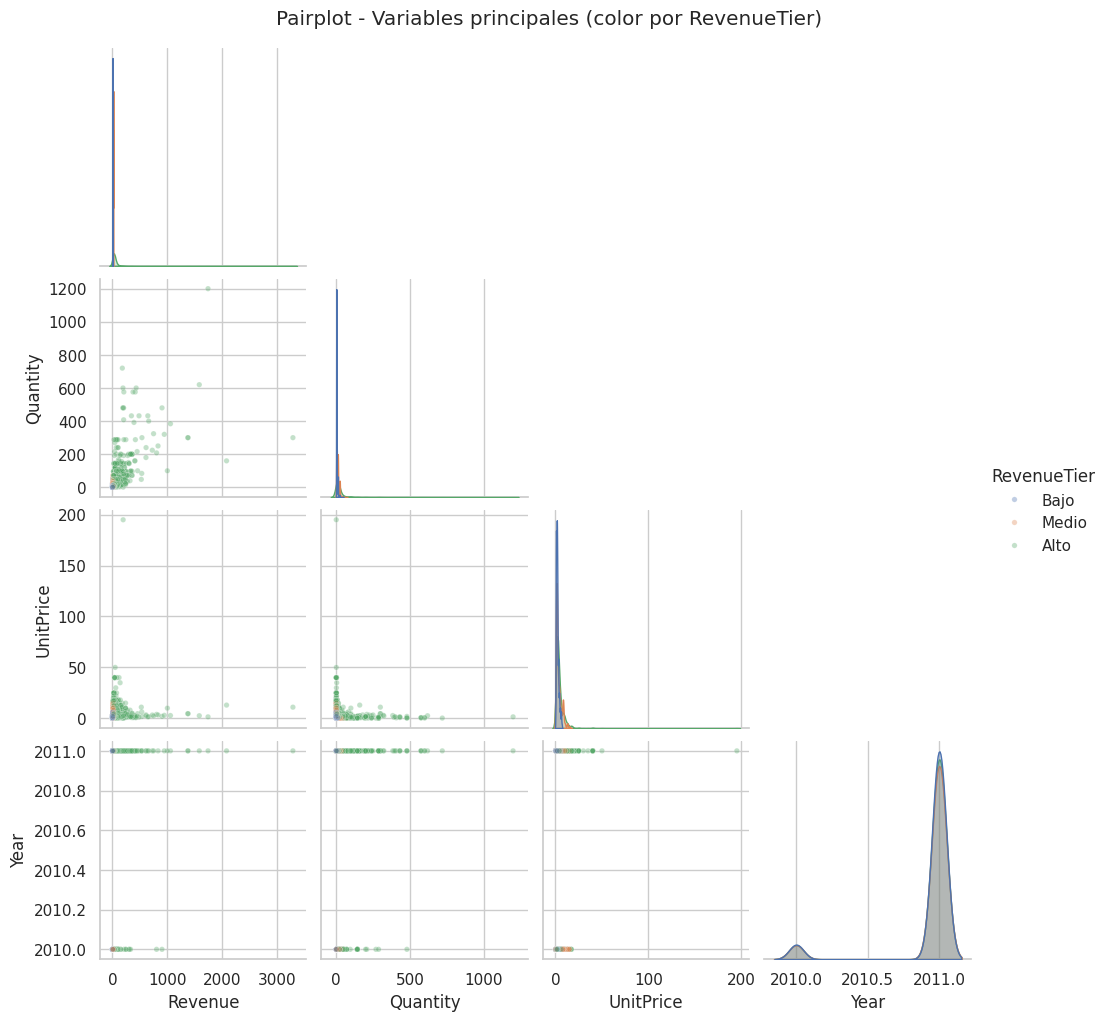

In [123]:
sns.set(style="whitegrid")

# Subconjunto de variables numéricas principales
num_cols = ['Revenue','Quantity','UnitPrice','Year']
df_num = df_clean[num_cols].dropna().copy()

# CATEGORÍA DE “CALIDAD”: tiers por Revenue (cuantiles 33/66%)
df_tiers = df_clean[['Revenue','Quantity','UnitPrice','Year','Country']].dropna().copy()
df_tiers['RevenueTier'] = pd.qcut(df_tiers['Revenue'], q=[0, 1/3, 2/3, 1], labels=['Bajo','Medio','Alto'])

# Muestra (opcional) para gráficos más ligeros
sample_pp = df_tiers.sample(n=min(8000, len(df_tiers)), random_state=42)

g = sns.pairplot(
    sample_pp[['Revenue','Quantity','UnitPrice','Year','RevenueTier']],
    vars=['Revenue','Quantity','UnitPrice','Year'],
    hue='RevenueTier',        # cambia a 'Country' si prefieres
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha':0.35, 's':15}
)
g.fig.suptitle('Pairplot - Variables principales (color por RevenueTier)', y=1.02)
plt.show()

Observamos
- Se observa una fuerte concentración de puntos en valores bajos para todas las variables y colas largas (outliers) en Revenue, Quantity y UnitPrice. El color por RevenueTier muestra que los casos Altos se ubican sobre todo en cantidades elevadas (y a veces con UnitPrice mayor), confirmando que el ingreso alto proviene principalmente de volumen y, en menor medida, de precio. Entre Quantity y UnitPrice se aprecia una relación inversa (compras grandes tienden a precios unitarios más bajos), mientras que Revenue vs Quantity sugiere asociación positiva no lineal. La variable Year está prácticamente concentrada en 2011, sin patrón diferenciador por tier. En conjunto: distribución muy asimétrica, presencia de outliers, y el volumen vendido como driver clave del revenue.


<br>

### **Gráficos de densidad**

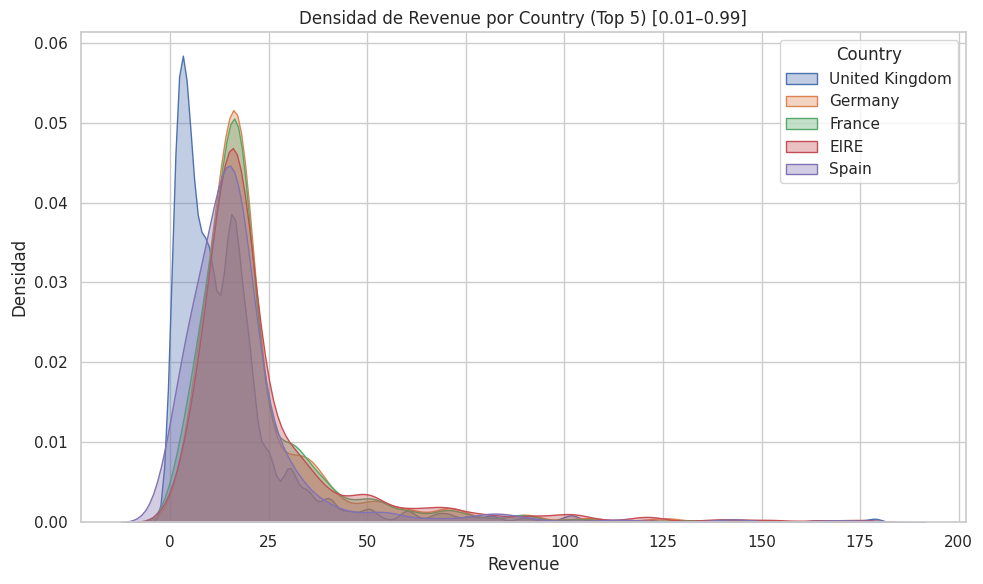

In [124]:
tipo_col = 'Country'
topN = 5
top_vals = df_clean[tipo_col].value_counts().head(topN).index

# Subconjunto con los países top
df_kde = df_clean[df_clean[tipo_col].isin(top_vals)].copy()

# --- Cálculo de límites de percentil globales (0.01–0.99) ---
low, high = df_kde['Revenue'].quantile([0.01, 0.99])
df_kde = df_kde[(df_kde['Revenue'] >= low) & (df_kde['Revenue'] <= high)]

# --- Gráfico de densidad ---
plt.figure(figsize=(10,6))
for val in top_vals:
    sns.kdeplot(
        data=df_kde[df_kde[tipo_col] == val],
        x='Revenue',
        fill=True,
        common_norm=False,
        alpha=0.35,
        label=str(val),
        bw_adjust=1.0
    )

plt.title(f'Densidad de Revenue por {tipo_col} (Top {topN}) [0.01–0.99]')
plt.xlabel('Revenue')
plt.ylabel('Densidad')
plt.legend(title=tipo_col)
plt.tight_layout()
plt.show()

Observamos
- Las curvas de densidad (recortadas al 1–99%) muestran distribuciones asimétricas a la derecha en todos los países: muchas transacciones de bajo Revenue y una cola larga de tickets altos. United Kingdom presenta una densidad más alta y más cercana a valores pequeños, indicando mayor frecuencia de pedidos de bajo monto (mercado de volumen). Germany, France, EIRE y Spain comparten una forma similar pero con el pico desplazado un poco a la derecha, sugiriendo un ticket típico algo mayor que el de UK. En todos los casos persisten colas derechas que reflejan ventas ocasionales de alto valor.

# **5. Actividades**

### **Ticket promedio por transacción**

In [125]:
ticket_por_factura = (
    df_clean.groupby('InvoiceNo', as_index=False)['Revenue'].sum()
    .rename(columns={'Revenue':'Ticket'})
)

ticket_promedio = ticket_por_factura['Ticket'].mean()
print(f" Ticket promedio por transacción: {ticket_promedio:,.2f}")

 Ticket promedio por transacción: 461.27


In [129]:
ticket_promedio_pais = (
    df_clean.groupby(['Country','InvoiceNo'])['Revenue'].sum()
    .groupby('Country').mean()
    .sort_values(ascending=False)
)
ticket_promedio_pais.round(2).head(30)

,Revenue
Country,
Singapore,3037.69
Netherlands,3032.30
Australia,2545.82
Japan,1963.91
Lebanon,1693.88
Israel,1443.17
Brazil,1143.60
Switzerland,1097.53
Sweden,1051.94


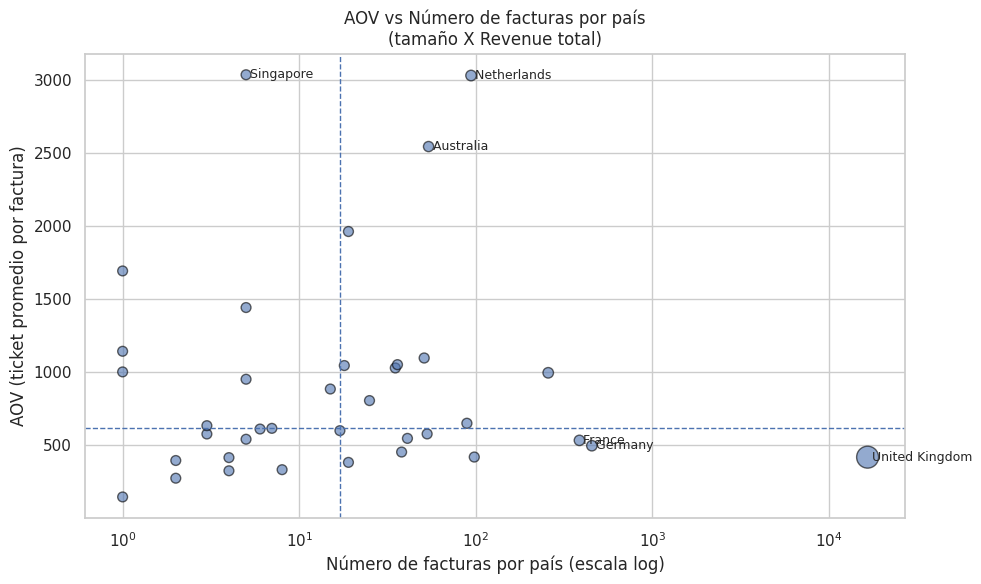

In [127]:
# Average Order Value o Valor Promedio del Pedido (AOV)

df_tx = (
    df_clean.loc[df_clean["Revenue"] > 0, ["Country", "InvoiceNo", "Revenue"]]
    .groupby(["Country","InvoiceNo"], as_index=False)["Revenue"].sum()
)

country_metrics = (
    df_tx.groupby("Country")
         .agg(
             n_invoices = ("InvoiceNo","nunique"),
             AOV        = ("Revenue","mean"),   # ticket promedio por factura
             rev_total  = ("Revenue","sum")
         )
         .reset_index()
)

# Escala de tamaño para la burbuja (revenue total)
size = 200 * (country_metrics["rev_total"] / country_metrics["rev_total"].max()) + 50

# Gráfico
plt.figure(figsize=(10,6))
plt.scatter(
    country_metrics["n_invoices"], country_metrics["AOV"],
    s=size, alpha=0.6, edgecolors="black"
)

plt.xscale("log")  # suele ayudar (gran diferencia de volumen entre países)
plt.xlabel("Número de facturas por país (escala log)")
plt.ylabel("AOV (ticket promedio por factura)")
plt.title("AOV vs Número de facturas por país\n(tamaño X Revenue total)")

# Líneas de referencia (medianas)
plt.axvline(country_metrics["n_invoices"].median(), ls="--", lw=1)
plt.axhline(country_metrics["AOV"].median(),      ls="--", lw=1)

# Etiquetas para países clave
destacados = {"United Kingdom","Singapore","Netherlands","France","Germany","Australia"}
for _, r in country_metrics.iterrows():
    if r["Country"] in destacados:
        plt.text(r["n_invoices"], r["AOV"], f" {r['Country']}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

Observamos
- El diagrama AOV vs # de facturas confirma dos perfiles claros: Reino Unido está en el cuadrante de alto volumen y bajo ticket (muchísimas facturas pero AOV ≈ 418, por debajo del promedio global 461), por eso su burbuja es la más grande (mayor revenue total). En cambio, Singapur y Países Bajos se ubican en alto AOV y bajo volumen (≈ 3.0k por factura), seguidos por Australia (≈ 2.5k), es decir, mercados premium con pocas transacciones pero de alto valor. Francia y Alemania aparecen con volumen medio/alto y AOV bajo–medio (~500). En conjunto, el negocio se sostiene por volumen en UK, mientras que el crecimiento de valor proviene de países premium donde conviene impulsar adquisición en UK.

<br>

### **Identificar productos más vendidos por mes**

In [130]:
df_prod = df_clean.copy()

# Ventas positivas (evita devoluciones)
ventas = df_prod[(df_prod["Quantity"] > 0) & (df_prod["Revenue"] > 0)].copy()

# Top por mes según Quantity
m_top = (
    ventas.groupby(["YearMonth","StockCode","Description"], as_index=False)
          .agg(Quantity=("Quantity","sum"), Revenue=("Revenue","sum"),
               n_invoices=("InvoiceNo","nunique"))
)
m_top["rank_qty"] = (m_top
                      .groupby("YearMonth")["Quantity"]
                      .rank(method="first", ascending=False))

m_top = (m_top.query("rank_qty == 1")
                  .sort_values(["YearMonth","Quantity"],
                               ascending=[True, False])
                  .reset_index(drop=True))

m_top.head(20)




,YearMonth,StockCode,Description,Quantity,Revenue,n_invoices,rank_qty
0,2010-12,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,5139,1150.47,29,1.0
1,2011-01,85123A,WHITE HANGING HEART T-LIGHT HOLDER,3531,10040.55,154,1.0
2,2011-02,22053,EMPIRE DESIGN ROSETTE,3986,3302.92,4,1.0
3,2011-03,85099B,JUMBO BAG RED RETROSPOT,4924,8496.88,119,1.0
4,2011-04,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,10224,2281.44,38,1.0
5,2011-05,22197,SMALL POPCORN HOLDER,6730,4971.70,73,1.0
6,2011-06,85099B,JUMBO BAG RED RETROSPOT,3529,6628.42,126,1.0
7,2011-07,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,3552,968.64,38,1.0
8,2011-08,84879,ASSORTED COLOUR BIRD ORNAMENT,6417,9652.41,102,1.0
9,2011-09,85099B,JUMBO BAG RED RETROSPOT,4175,7987.85,183,1.0


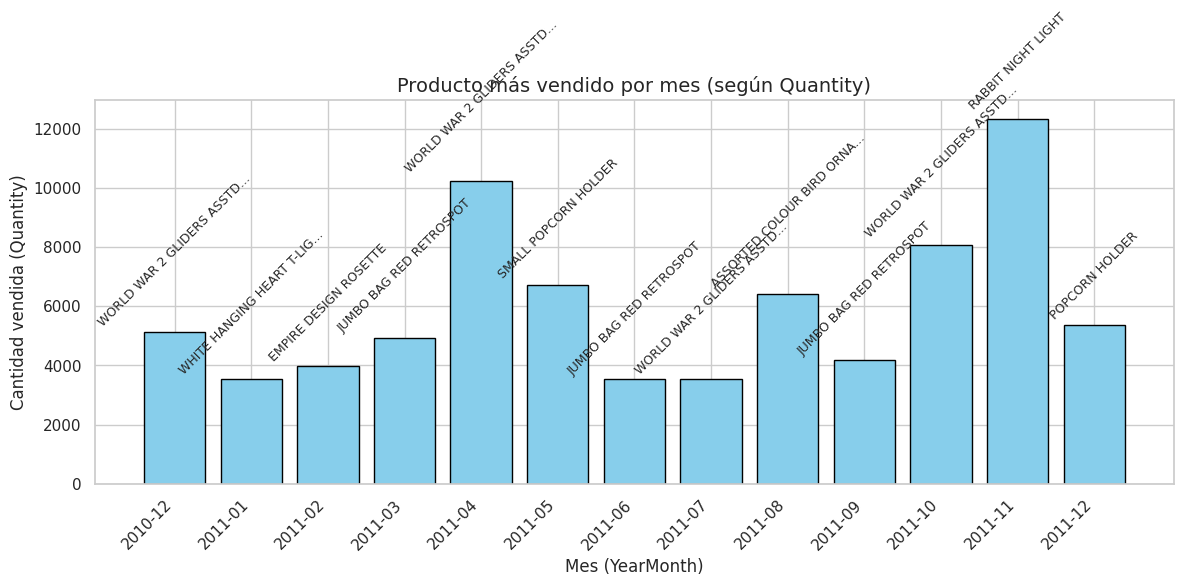

In [131]:
# Aseguramos orden cronológico
m_top = m_top.sort_values("YearMonth")

plt.figure(figsize=(12, 6))
bars = plt.bar(m_top["YearMonth"].astype(str), m_top["Quantity"], color="skyblue", edgecolor="black")

# Etiquetas de producto sobre cada barra
for i, row in m_top.iterrows():
    plt.text(row["YearMonth"].strftime("%Y-%m"),
             row["Quantity"] + (row["Quantity"] * 0.02),
             row["Description"][:25] + ("..." if len(row["Description"]) > 25 else ""),
             ha="center", va="bottom", fontsize=9, rotation=45)

plt.title("Producto más vendido por mes (según Quantity)", fontsize=14)
plt.xlabel("Mes (YearMonth)")
plt.ylabel("Cantidad vendida (Quantity)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Observamos
- El gráfico muestra la evolución de los productos más vendidos por mes en función de la cantidad total despachada (Quantity), revelando las variaciones en la demanda a lo largo del periodo analizado. Se observa que los productos con mayores volúmenes corresponden a artículos de regalo o decoración, como “World War 2 Gliders Asstd Designs”, “Medium Ceramic Top Storage Jar” y “Rabbit Night Light”, que destacan como los más vendidos en distintos meses. La tendencia sugiere un comportamiento estacional de las ventas, con picos notables en abril y noviembre, posiblemente asociados a campañas de primavera y fin de año, mientras que en los meses intermedios las ventas mantienen niveles moderados. En general, el patrón evidencia una rotación constante de productos líderes, lo que indica una diversidad en la preferencia del consumidor y la importancia de mantener un portafolio variado para sostener las ventas.

<br>

### **Patrones de compra por país**


In [132]:
# --- Países a analizar ---
paises = ["United Kingdom","Singapore","Netherlands","France","Germany","Australia"]
df_pais = df_clean[df_clean['Country'].isin(paises)].copy()

# --- Asegurar tipo de fecha correcto ---
if isinstance(df_pais['YearMonth'].dtype, pd.PeriodDtype):
    df_pais['YearMonth'] = df_pais['YearMonth'].dt.to_timestamp()
else:
    df_pais['YearMonth'] = pd.to_datetime(df_pais['YearMonth'], errors='coerce')

# --- Volumen mensual de ingresos ---
ventas = (
    df_pais.groupby(['Country','YearMonth'], as_index=False)
           .agg(Revenue=('Revenue','sum'))
)

# --- Ingreso promedio por factura ---
ticket_factura = (
    df_pais.groupby(['Country','YearMonth','InvoiceNo'], as_index=False)['Revenue']
           .sum()
           .rename(columns={'Revenue':'Ticket'})
)
ticket_prom = (
    ticket_factura.groupby(['Country','YearMonth'], as_index=False)['Ticket']
                  .mean()
                  .rename(columns={'Ticket':'TicketPromedio'})
)

# --- Merge final ---
patrones_pais = ventas.merge(ticket_prom, on=['Country','YearMonth'], how='left')
patrones_pais = patrones_pais.sort_values(['YearMonth','Country'])

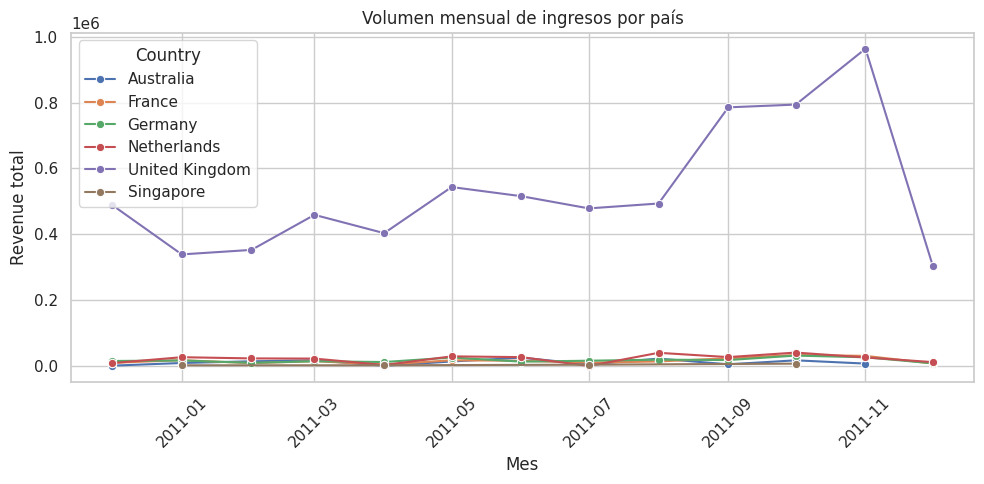

In [133]:
plt.figure(figsize=(10,5))
sns.lineplot(data=patrones_pais, x='YearMonth', y='Revenue', hue='Country', marker='o')
plt.title('Volumen mensual de ingresos por país')
plt.ylabel('Revenue total')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

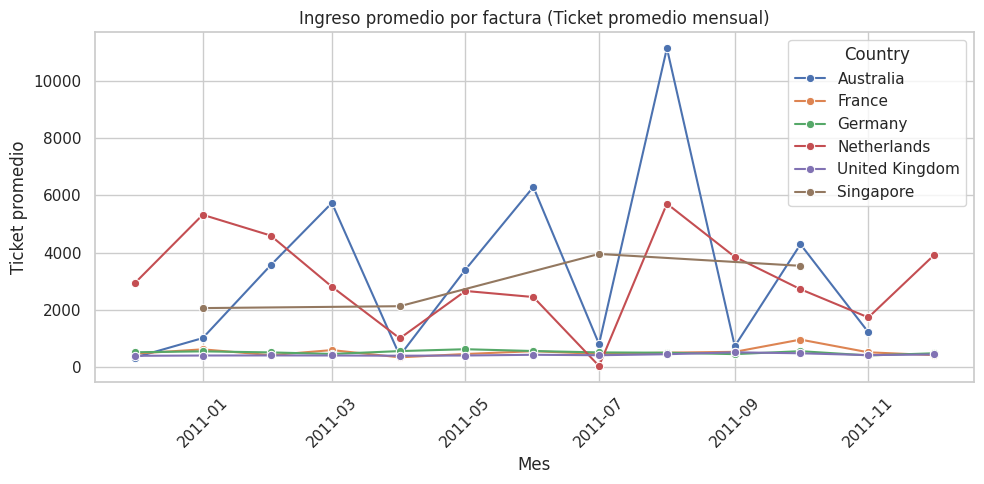

In [134]:
plt.figure(figsize=(10,5))
sns.lineplot(data=patrones_pais, x='YearMonth', y='TicketPromedio', hue='Country', marker='o')
plt.title('Ingreso promedio por factura (Ticket promedio mensual)')
plt.ylabel('Ticket promedio')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observamos
- En conjunto, los gráficos confirman dos perfiles claros: UK domina el volumen de ingresos mes a mes (picos en sep–nov), pero con ticket promedio (AOV) bajo y estable, es decir, su liderazgo se explica por muchas facturas más que por valor por pedido. Por el contrario, Singapore, Netherlands y Australia exhiben AOV alto y volátil (picos puntuales), pero con volumen pequeño; Francia y Alemania se mantienen en niveles moderados y estables en ambas métricas. En síntesis: el crecimiento total proviene del volumen en UK, mientras que el valor unitario está en mercados “premium”; tacticamente, upsell/bundles en UK

<br>

### **Clientes de alto valor (RFM básico)**

In [138]:
# --- Fecha de referencia (ya la tienes) ---
ref_date = df_clean['InvoiceDate'].max().normalize()

# --- RFM base ---
rfm = (
    df_clean.groupby('CustomerID').agg(
        Recency=('InvoiceDate', lambda s: (ref_date - s.max().normalize()).days),
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('Revenue', 'sum')
    ).dropna()
)

# --- País dominante por Revenue (por cliente) ---
pais_cliente = (
    df_clean.groupby(['CustomerID','Country'], as_index=False)['Revenue'].sum()
             .sort_values(['CustomerID','Revenue'], ascending=[True, False])
             .drop_duplicates(subset=['CustomerID'])
             .rename(columns={'Country':'CountryDominant', 'Revenue':'RevenuePaisDominante'})
             .set_index('CustomerID')
)

rfm = rfm.join(pais_cliente[['CountryDominant']], how='left')

# --- Cuantiles para R, F, M (1=peor, 4=mejor) ---
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['RFM_Score'] = rfm[['R','F','M']].astype(int).sum(axis=1)

# --- Top clientes de alto valor ---
clientes_alto_valor = (
    rfm.sort_values(['RFM_Score','Monetary','Frequency'], ascending=False)
       .head(20)
       .reset_index()
)

clientes_alto_valor[['CustomerID','CountryDominant','Recency','Frequency','Monetary','R','F','M','RFM_Score']]

,CustomerID,CountryDominant,Recency,Frequency,Monetary,R,F,M,RFM_Score
0,14646.0,Netherlands,1,73,279846.02,4,4,4,12
1,18102.0,United Kingdom,0,60,259657.30,4,4,4,12
2,17450.0,United Kingdom,8,45,189607.53,4,4,4,12
3,14911.0,EIRE,1,198,137166.67,4,4,4,12
4,14156.0,EIRE,9,55,114516.28,4,4,4,12
5,17511.0,United Kingdom,2,30,88556.38,4,4,4,12
6,16684.0,United Kingdom,4,28,65920.12,4,4,4,12
7,14096.0,United Kingdom,4,17,65164.79,4,4,4,12
8,13694.0,United Kingdom,3,50,63555.30,4,4,4,12
9,15311.0,United Kingdom,0,90,59857.16,4,4,4,12


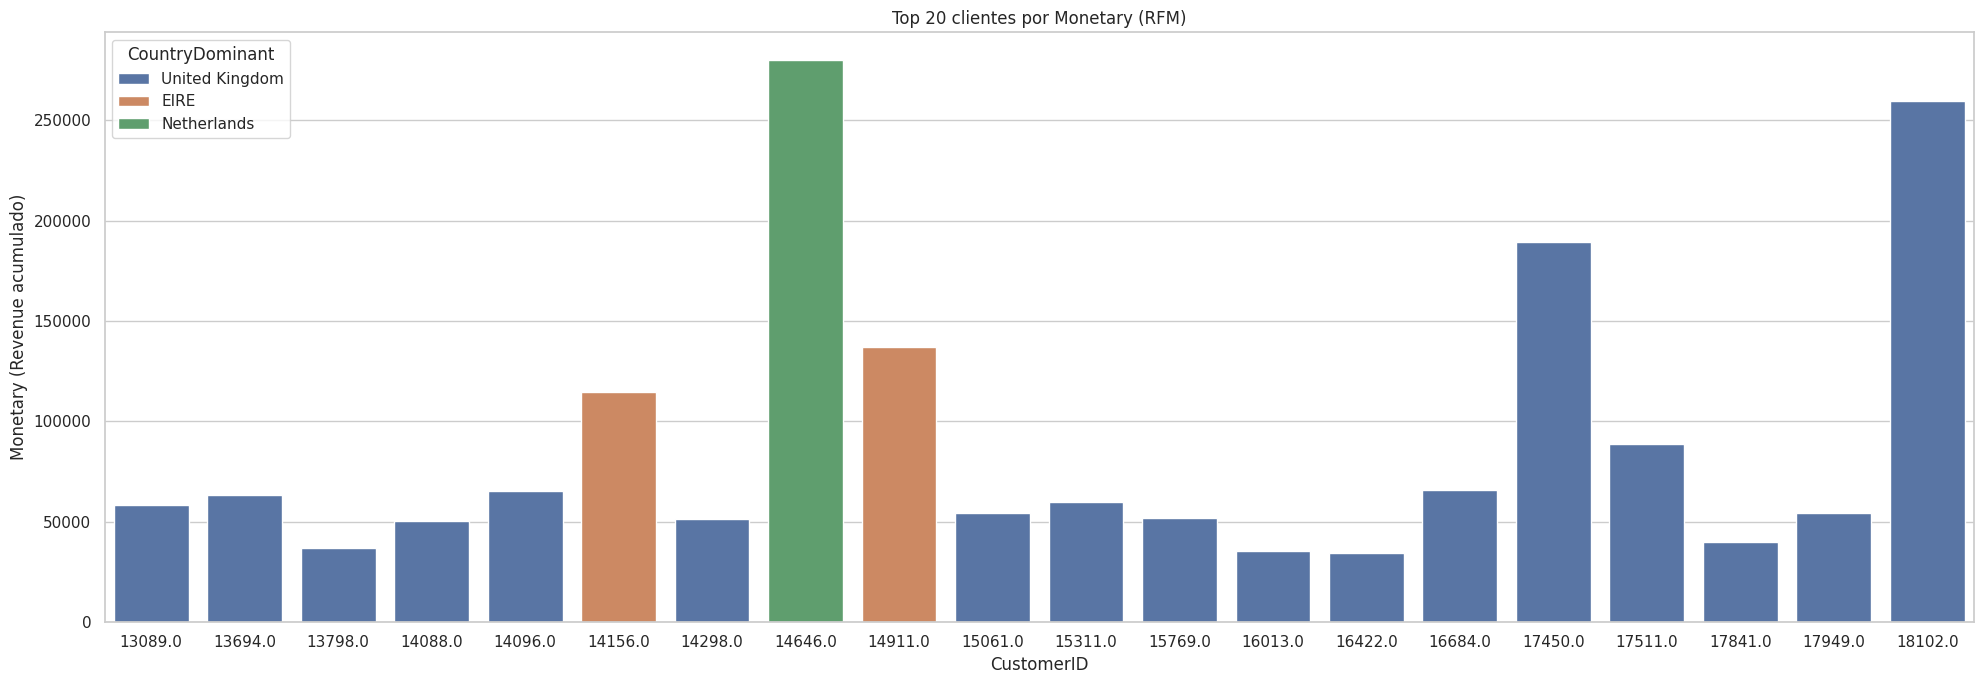

In [136]:
top20 = clientes_alto_valor.sort_values('Monetary', ascending=True)

plt.figure(figsize=(20,7))
sns.barplot(data=top20, y='Monetary', x='CustomerID', hue='CountryDominant', dodge=False)
plt.title('Top 20 clientes por Monetary (RFM)')
plt.xlabel('CustomerID')
plt.ylabel('Monetary (Revenue acumulado)')
plt.tight_layout()
plt.show()

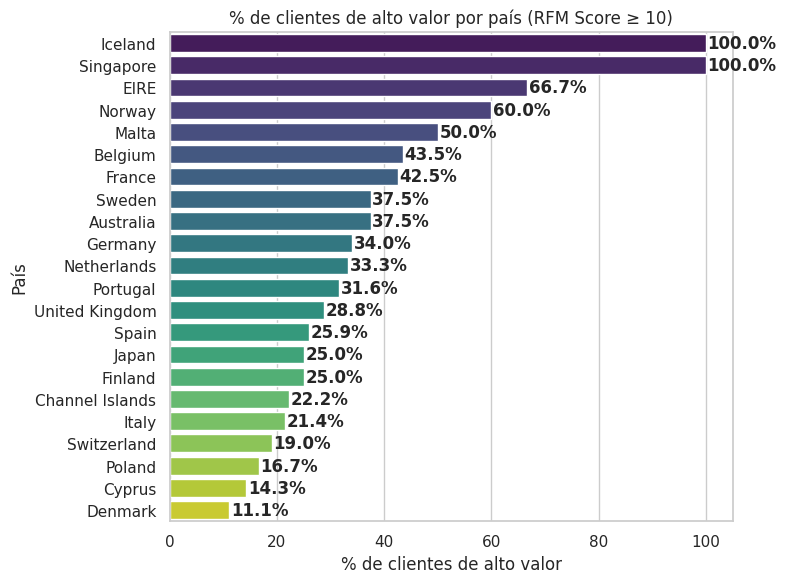

In [137]:
umbral_alto = 10
rfm["HighValue"] = rfm["RFM_Score"] >= umbral_alto

share_high = (
    rfm.groupby("CountryDominant")["HighValue"].mean() * 100
).sort_values(ascending=False)

share_high = share_high[share_high > 0]

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=share_high.reset_index(),
    x="HighValue", y="CountryDominant",
    hue="CountryDominant",  # define hue explícitamente
    palette="viridis",
    legend=False
)

# etiquetas con los porcentajes
for i, v in enumerate(share_high.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.title(f"% de clientes de alto valor por país (RFM Score ≥ {umbral_alto})")
plt.xlabel("% de clientes de alto valor")
plt.ylabel("País")
plt.tight_layout()
plt.show()


Observamos
- Se ve una cartera bimodal: el Top 20 por Monetary está dominado en número por United Kingdom, pero los tickets acumulados más altos provienen de clientes puntuales de Netherlands y EIRE (picos >200k), es decir, pocas cuentas muy grandes fuera de UK. Al mirar el % de clientes de alto valor (RFM ≥ 10) por país, mercados pequeños como Iceland y Singapore concentran casi todos sus clientes en el segmento premium (probable N bajo), mientras que UK, pese a su tamaño, solo tiene ~29% de alto valor: mucho volumen pero menor valor unitario. Implicación: priorizar fidelización/VIP en Netherlands/EIRE/Singapore


<br>

### **Evolución de ventas semanales**


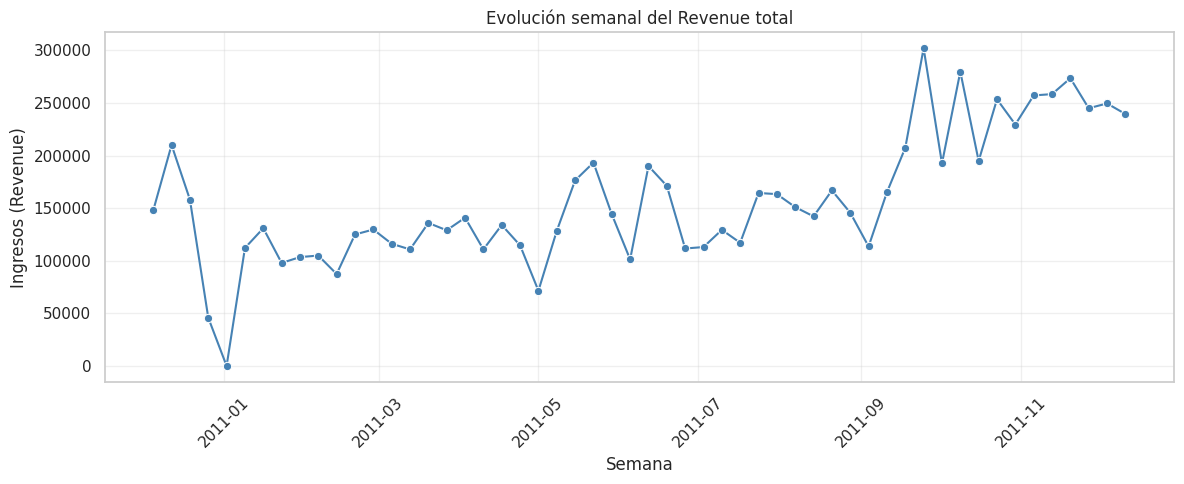

In [139]:
ventas_semanales = (
    df_clean.set_index('InvoiceDate')
    .resample('W')['Revenue'].sum()
    .reset_index()
)

plt.figure(figsize=(12,5))
sns.lineplot(data=ventas_semanales, x='InvoiceDate', y='Revenue', marker='o', color='steelblue')
plt.title('Evolución semanal del Revenue total')
plt.xlabel('Semana')
plt.ylabel('Ingresos (Revenue)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Observamos
- El gráfico muestra la evolución semanal del ingreso total (Revenue) y evidencia un comportamiento cíclico con tendencia creciente hacia el último trimestre de 2011.
Durante las primeras semanas, los ingresos presentan alta volatilidad, con caídas marcadas que podrían corresponder a semanas de baja demanda o ajustes operativos. A partir de mediados de año, la serie muestra una recuperación sostenida y mayor estabilidad, y entre septiembre y noviembre se observa el pico más alto, coincidente con la temporada de compras de fin de año (Black Friday, Navidad, etc.).
En resumen, el patrón sugiere una aceleración progresiva en las ventas con estacionalidad positiva al cierre del año, reflejando oportunidades para reforzar estrategias de marketing y abastecimiento en esos meses clave.

<br>

### **Identificar productos con mayor cancelación**

In [140]:
df2 = df.copy()

# Normaliza lo mínimo necesario (pero NO la clave)
df2['InvoiceNo'] = df2['InvoiceNo'].astype(str)
df2['Description_clean'] = (df2['Description'].str.strip()
                                           .str.replace(r'\s+', ' ', regex=True))

# Marca notas de crédito
df2['is_credit'] = df2['InvoiceNo'].str.startswith('C')

# Ventas y cancelaciones por StockCode
vend = (df2[~df2['is_credit']]
        .groupby('StockCode', as_index=False)['Quantity'].sum()
        .rename(columns={'Quantity':'QtyVendida'}))

canc = (df2[df2['is_credit']]
        .groupby('StockCode', as_index=False)['Quantity']
        .apply(lambda s: np.abs(s).sum())
        .rename(columns={'Quantity':'QtyCancelada'}))

rates = (vend.merge(canc, on='StockCode', how='left')
              .fillna({'QtyCancelada':0})
              .assign(CancelRate=lambda d: np.where(d['QtyVendida']>0,
                                                    d['QtyCancelada']/d['QtyVendida'],
                                                    np.nan)))

# Adjunta una descripción representativa (la más frecuente por StockCode)
desc_rep = (df2.groupby(['StockCode','Description_clean'])
               .size().reset_index(name='n')
               .sort_values(['StockCode','n'], ascending=[True,False])
               .drop_duplicates('StockCode')
               .rename(columns={'Description_clean':'Description'}))

rates = rates.merge(desc_rep[['StockCode','Description']], on='StockCode', how='left')

umbral_min_vtas = 50
topN = 20
print(rates.query('QtyVendida >= @umbral_min_vtas')
                    .sort_values('CancelRate', ascending=False)
                    .head(topN))

     StockCode  QtyVendida  QtyCancelada  CancelRate                          Description
1954     23055         260         432.0    1.661538      IVORY CHANDELIER T-LIGHT HOLDER
2731    47566B        1082        1424.0    1.316081               TEA TIME PARTY BUNTING
2505     23843       80995       80995.0    1.000000          PAPER CRAFT , LITTLE BIRDIE
3029     84347        9476        9376.0    0.989447  ROTATING SILVER ANGELS T-LIGHT HLDR
2059     23166       78033       74494.0    0.954647       MEDIUM CERAMIC TOP STORAGE JAR
3642    85232B         280         255.0    0.910714      SET OF 3 BABUSHKA STACKING TINS
1956     23057         496         433.0    0.872984     BEADED CHANDELIER T-LIGHT HOLDER
1955     23056         756         579.0    0.765873    FLOWERS CHANDELIER T-LIGHT HOLDER
3420    85023B         105          73.0    0.695238      EAU DE NILE JEWELLED PHOTOFRAME
740      21655          55          36.0    0.654545   HANGING RIDGE GLASS T-LIGHT HOLDER
2854    72

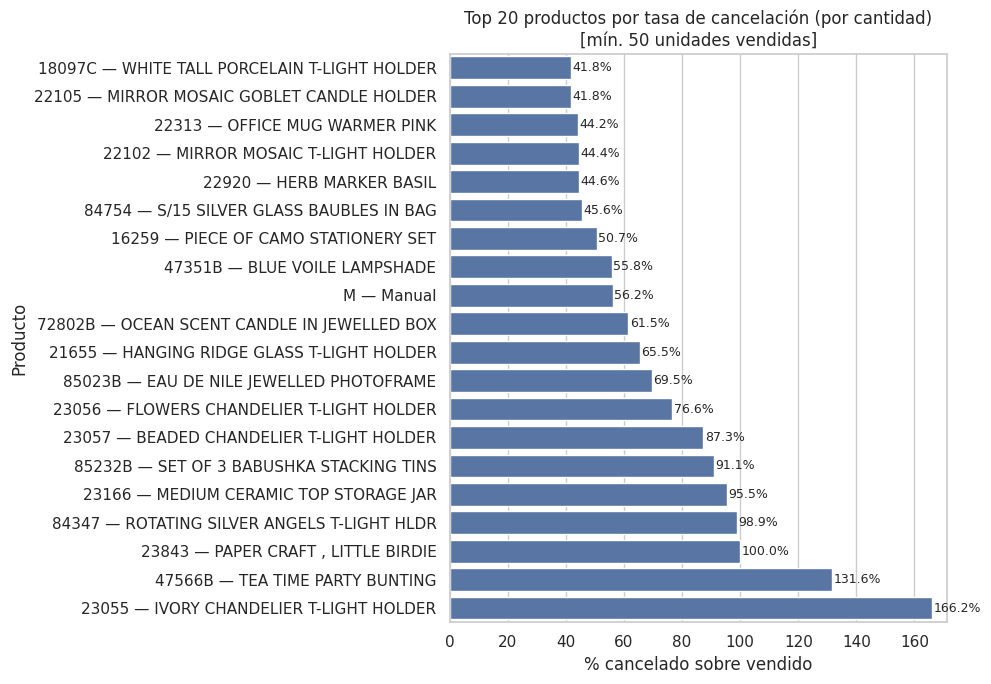

In [141]:

top_cancel = (rates.query('QtyVendida >= @umbral_min_vtas')
                    .sort_values('CancelRate', ascending=False)
                    .head(topN)
                    .assign(CancelRatePct=lambda d: 100*d['CancelRate'],
                            label=lambda d: d['StockCode'].astype(str)+' — '+d['Description'])
             )

# Plot
data_plot = top_cancel.sort_values('CancelRatePct', ascending=True)

plt.figure(figsize=(10,7))
ax = sns.barplot(data=data_plot, x='CancelRatePct', y='label', orient='h', errorbar=None)
for i, v in enumerate(data_plot['CancelRatePct']):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)

ax.set_title(f"Top {topN} productos por tasa de cancelación (por cantidad)\n[mín. {umbral_min_vtas} unidades vendidas]")
ax.set_xlabel('% cancelado sobre vendido')
ax.set_ylabel('Producto')
# Permite ver >100 %
ax.set_xlim(0, max(110, data_plot['CancelRatePct'].max()+5))
plt.tight_layout()
plt.show()


In [142]:
df[df['StockCode']=='23843']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,9/12/2011 09:15,2.08,16446.0,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,9/12/2011 09:27,2.08,16446.0,United Kingdom


Observamos

- El análisis de tasa de cancelación por producto revela problemas puntuales: varios ítems superan 100 % (p. ej., IVORY CHANDELIER T-LIGHT HOLDER ≈166 % y TEA TIME PARTY BUNTING ≈132 %), lo que implica más unidades devueltas que vendidas en el periodo. El grupo con mayor incidencia son accesorios de iluminación y decoración (candelabros, t-light holders, photoframes), además de algunos códigos “Manual”, lo que sugiere errores de picking/codificación, expectativa vs. realidad en el producto o estacionalidad mal calibrada. Recomendación rápida: auditar fichas y fotos, revisar calidad/packaging y vigilar reposiciones para evitar sobrestock en artículos con cancelación crónica.

<br>

# **6. Insigth**

**El driver del Revenue es el volumen**

Quantity tiene correlación fuerte con Revenue (ρ≈0.65) y UnitPrice solo moderada (ρ≈0.35); variables de calendario aportan poco. VIF ~1 en todos los predictores (sin multicolinealidad).

Acción: optimiza upsell/bundles y “multi‐unidad” (mínimos de compra, packs) para elevar cantidad por ticket.

<br>

**Dos arquetipos de mercado, estrategias distintas**

UK: muchísimo volumen pero AOV bajo (≈ 418; burbuja más grande por revenue total).
Singapore/Netherlands/Australia: AOV alto (~2.5–3.0k) con bajo volumen.
Acción: en UK empuja bundles, cross-sell y suscripciones; en mercados premium enfoca adquisición/penetración y cuentas corporativas.

<br>

**Temporalidad operativa clara**

Picos semanales y mensuales en Q4 (sep–nov); viernes y 07:00 marcan máximos diarios/horarios.
Acción: refuerza inventario, marketing y personal en Q4, especialmente viernes y primeras horas; programa campañas y drops a las 07:00.

<br>

**Liderazgo de productos es rotativo y estacional**
Mes a mes cambian los #1 (ej. “Medium Ceramic Top Storage Jar” en ene-2011; “Rabbit Night Light” en dic-2011).
Acción: mantén portafolio dinámico y planeación por Top-3 por mes/país.

<br>

**Alertas críticas de cancelación/devolución por SKU**

Varios productos exhiben tasas >100% (p.ej., IVORY CHANDELIER T-LIGHT HOLDER ≈ 166%), concentrados en iluminación/decoración.
👉 Acción inmediata: auditoría de calidad/fichas/fotos, revisar packaging y códigos; ajustar precios/stock o descontinuar; política de devoluciones específica para esos SKUs.

